# IQR Outlier Detection and Removal

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../../DATASETS/placement.csv")

In [39]:
df.shape

(1000, 3)

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [6]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


C:\Users\admin\AppData\Local\Temp\ipykernel_10360\3094801577.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


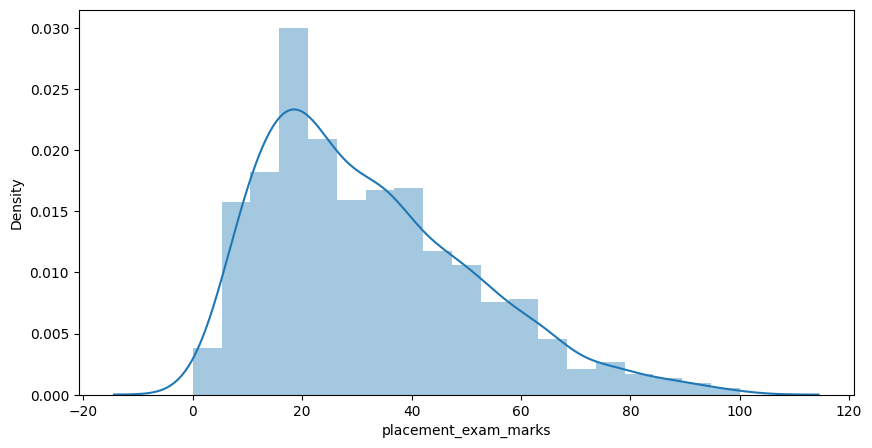

In [25]:
plt.figure(figsize = (10,5))
plt.subplot(1,1,1)
sns.distplot(df['placement_exam_marks'])

plt.show()
# There is skewness in data therefore we plot box plot to detect and remove outliers.

<Axes: ylabel='placement_exam_marks'>

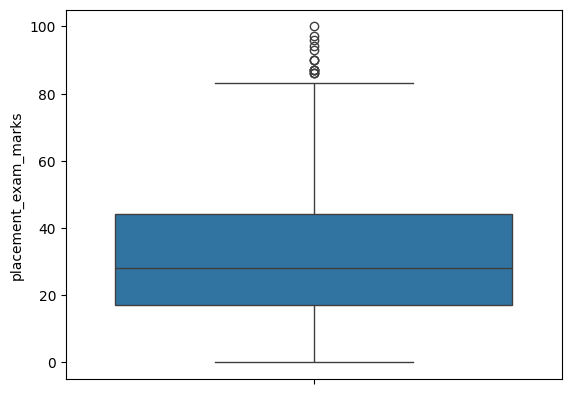

In [49]:
# df['placement_exam_marks'].plot(kind = 'box')
# there are outliers only at oe side

sns.boxplot(df['placement_exam_marks'])

In [33]:
# Finding the quartile i.e Q1 and Q3

quantile25 = df['placement_exam_marks'].quantile(0.25)
quantile75 = df['placement_exam_marks'].quantile(0.75)

print(quantile25)
print(quantile75)

17.0
44.0


In [50]:
# IQR = Q3 - Q1

IQR = quantile75 - quantile25

In [51]:
IQR

np.float64(27.0)

In [52]:
upper_limit = quantile75 + 1.5 * IQR
lower_limit = quantile25 - 1.5 * IQR

In [53]:
upper_limit

np.float64(84.5)

In [54]:
lower_limit

np.float64(-23.5)

# Trimming

In [66]:
new_df = df[(df['placement_exam_marks'] < upper_limit) & (df['placement_exam_marks'] > lower_limit)]

In [67]:
new_df.shape

(985, 3)

In [68]:
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\admin\AppData\Local\Temp\ipykernel_10360\2198556207.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

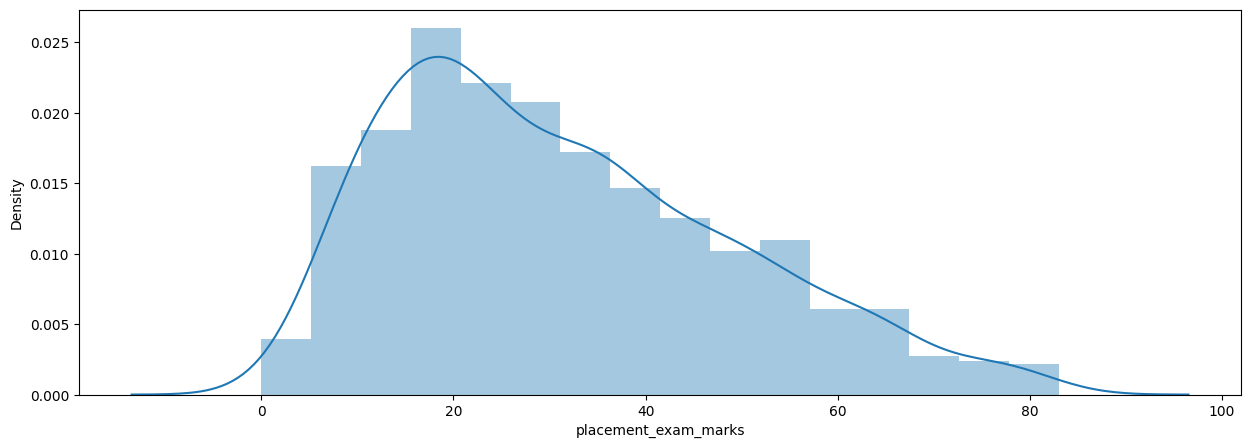

In [92]:
plt.figure(figsize = (15,5))
sns.distplot(new_df['placement_exam_marks'])

<Axes: ylabel='placement_exam_marks'>

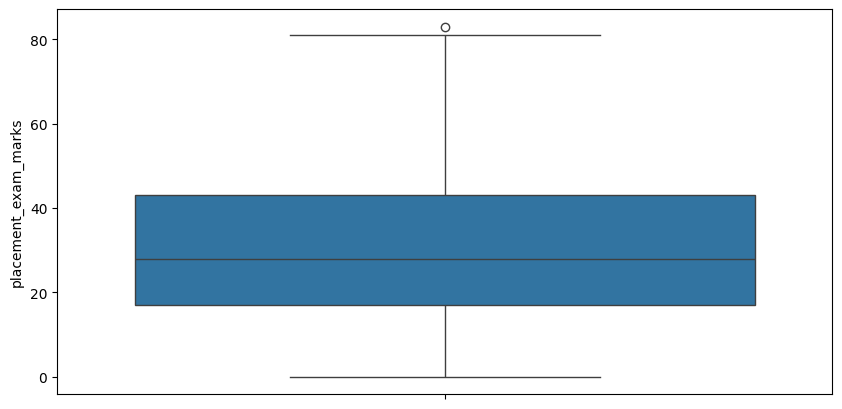

In [70]:
plt.figure(figsize = (10,5))
sns.boxplot(new_df['placement_exam_marks'])

In [71]:
# Outliers are removed

# Capping

In [73]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [74]:
upper_level = quantile75 + 1.5 * IQR 
lower_level = quantile25 - 1.5 * IQR


In [76]:
upper_level

np.float64(84.5)

In [77]:
lower_level

np.float64(-23.5)

In [84]:
# Capping 
df['placement_exam_marks'] = np.where(
    df['placement_exam_marks'] > upper_level,
    upper_level,
    np.where(df['placement_exam_marks'] < lower_level,
    lower_level,
    df['placement_exam_marks'])
)

In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [88]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.136500,0.489000
std,0.615898,18.865419,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,84.500000,1.000000


<Figure size 2000x1000 with 0 Axes>

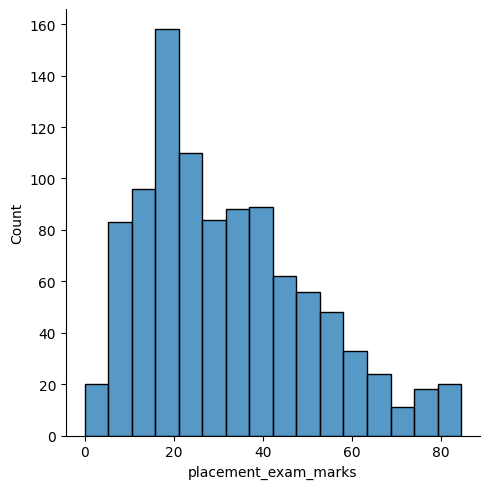

In [90]:
plt.figure(figsize = (20,10))
sns.displot(df['placement_exam_marks'])


<Axes: ylabel='placement_exam_marks'>

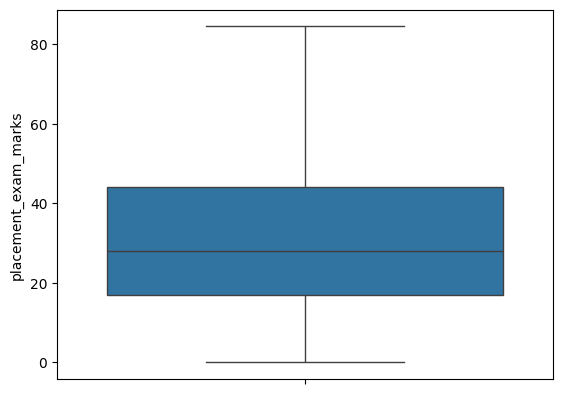

In [93]:
sns.boxplot(df['placement_exam_marks'])

In [94]:
df.shape

(1000, 3)